# Cascade Variants — Scaling with ALSSM Order N [ex133.2]

Sweeps **polynomial degree** (poly_degree = 1 … 7, N = 2 … 8) to show how the four cascade
variants from [ex133.1](example-ex133.1-cascade-variants.ipynb) scale with the ALSSM state-space dimension.
All cascade setup (`build_cascade_inputs`, variant closures) follows **[ex133.1](example-ex133.1-cascade-variants.ipynb)**. Signal length
and segment are fixed.

| Axis | Value |
|------|-------|
| Signal length K | 1 000 000 (fixed) |
| Segment | `a=−21, b=−1, direction=FW, g=100` |
| Swept parameter | `poly_degree` ∈ {1, 2, 3, 4, 5, 6, 7} → **N** ∈ {2, 3, 4, 5, 6, 7, 8} |

**Four variants** (identical to ex133.1):

| # | Label | xi0 buffer | xi order |
|---|-------|:----------:|:--------:|
| 1 | Original | yes (C) | C |
| 2 | In-place | no | C |
| 3 | F-order | yes (F) | F |
| 4 | F-order + in-place | no | F |

**Why operations scale with N**:
- `lfilter` calls: N (one per dimension)
- coupling `einsum` calls: N − 1, each of cost O(K·N) → total O(K·N²)
- write bytes (in-place): K·N·8 bytes; (scratch variants): 3·K·N·8 bytes

**Series:**
- **[ex133.0](example-ex133.0-profile.ipynb)** — baseline profiling, hotspot identification
- **[ex133.1](example-ex133.1-cascade-variants.ipynb)** — same four variants at the fixed N=2 production model
- **[ex133.2](example-ex133.2-profile-higher-order.ipynb)** ← this notebook — N sweep
- **[ex133.3](example-ex133.3-applied.ipynb)** — before/after pipeline benchmark of the applied optimization


In [1]:
import io, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, matrix_power as _mpow
from scipy.signal import lfilter as _scipy_lf
import lmlib as lm

lm.WARNING_NOT_STEADY_STATE = False

## Configuration

In [2]:
K        = 1_000_000          # fixed signal length
N_time   = 20                  # timing repetitions per (variant, N)
N_mem    = 10                  # tracemalloc repetitions

# Segment shared across all orders
seg_l = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)

poly_degrees = [1, 2, 3, 4, 5, 6, 7]   # N = poly_degree + 1
N_orders     = [p + 1 for p in poly_degrees]

bar_cols = [lm.NORD['blue'], lm.NORD['yellow'], lm.NORD['green'], lm.NORD['red']]
var_labels = [
    'Original (C + xi0)',
    'In-place (C, no xi0)',
    'F-order  (F + xi0)',
    'F-order + in-place (F)',
]
_has_xi0 = [True, False, True, False]
_ord     = ['C', 'C', 'F', 'F']

print(f"K={K:,}, poly_degrees={poly_degrees}")
print(f"N_orders={N_orders}")

K=1,000,000, poly_degrees=[1, 2, 3, 4, 5, 6, 7]
N_orders=[2, 3, 4, 5, 6, 7, 8]


## Helper: build cascade inputs & variant closures

For each ALSSM order N the pre-computed cascade coefficients (`gAinvT`, `y_diff_master`, `gamma_inv`)
differ.  `build_cascade_inputs` replicates the precomputation from `lfilter_forward_cascade_xi`.
`make_variants` returns four callable closures that capture those coefficients.

In [3]:
def build_cascade_inputs(poly_degree, seg, K):
    """Precompute y_diff_master and cascade coefficients for a given poly_degree."""
    alssm = lm.AlssmPoly(poly_degree=poly_degree)
    A  = alssm.A.copy()
    C  = np.atleast_2d(alssm.C).copy()  # (1, N)
    N  = A.shape[1]

    a, b, d, g = seg.a, seg.b, seg.delta, seg.gamma
    ginv = 1.0 / g
    gAinvT = (ginv * inv(A).T).copy()

    Abc_vec = (_mpow(A, b).T    @ C.T).copy()
    Aac_vec = (_mpow(A, 0 if np.isinf(a) else a - 1).T @ C.T).copy()
    gb = g ** (b - d)
    ga = g ** (a - 1 - d)

    rng  = np.random.default_rng(42)
    y    = rng.standard_normal(K)
    vy   = y.reshape(-1, 1)

    yd_b        = np.empty_like(vy)
    yd_b[:-b]   = 0
    yd_b[-b:]   = vy[:b]
    ydiff       = np.einsum('kl,nl->kn', yd_b, gb * Abc_vec)

    yd_a          = np.empty_like(vy)
    yd_a[:-a+1]   = 0
    yd_a[-a+1:]   = vy[:a-1]
    ydiff        -= np.einsum('kl,nl->kn', yd_a, ga * Aac_vec)

    y_diff_master = np.ascontiguousarray(np.swapaxes(ydiff, 0, 1))  # (N, K)
    return y_diff_master, gAinvT, ginv, N


def make_variants(gAinvT, ginv, N):
    """Return four cascade closures for the given gAinvT / ginv / N."""

    def v_original(y_diff, xi):
        xi0 = np.zeros(xi.shape, order='C')
        n_ = 0
        xi0[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        for n_ in range(1, N):
            y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], gAinvT[n_])
            xi0[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        xi += xi0

    def v_inplace(y_diff, xi):
        n_ = 0
        xi[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        for n_ in range(1, N):
            y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi[:-1], gAinvT[n_])
            xi[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T

    def v_forder(y_diff, xi):
        xi0 = np.zeros(xi.shape, order='F')
        n_ = 0
        xi0[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        for n_ in range(1, N):
            y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], gAinvT[n_])
            xi0[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        xi += xi0

    def v_forder_inplace(y_diff, xi):
        n_ = 0
        xi[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T
        for n_ in range(1, N):
            y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi[:-1], gAinvT[n_])
            xi[:, n_] = _scipy_lf([1, 0], [1, -ginv], y_diff[n_].T).T

    return [v_original, v_inplace, v_forder, v_forder_inplace]


print("Helpers defined.")

# Quick sanity check at N=2
_ydm_test, _gAt_test, _ginv_test, _N_test = build_cascade_inputs(1, seg_l, 1000)
_vfns_test = make_variants(_gAt_test, _ginv_test, _N_test)
_xi_test = np.zeros((1000, _N_test), order='F')
_vfns_test[0](_ydm_test.copy(), _xi_test)
print(f"Sanity check passed: xi.shape={_xi_test.shape}, max={np.abs(_xi_test).max():.3f}")

Helpers defined.
Sanity check passed: xi.shape=(1000, 2), max=152.005


## Correctness check

Compare all four variants against `lfilter_forward_cascade_xi` (the reference) at each polynomial degree.

> **Note on `y` shape**: inside `lfilter_forward_cascade_xi`, `vy = y * v[:, None]`.
> Passing a 1-D `y` of shape `(K,)` causes NumPy to broadcast to a `(K, K)` outer-product, which is wrong.
> The reference must be called with `y` of shape `(K, 1)` to match the precompute used in the variants.

Tiny numeric discrepancies between C-order and F-order variants at large N are expected (different
memory-access order changes floating-point rounding); these are well within `np.allclose` relative tolerance.

In [4]:
from lmlib.statespace.backends.rec_lfilter import lfilter_forward_cascade_xi as _ref_cascade

K_check = 3_000   # small K keeps this fast

print(f"{'pd':>3}  {'N':>2}  {'original':>10}  {'inplace':>10}  {'forder':>10}  {'forder_ip':>10}")
print("-" * 52)

for p in poly_degrees:
    N = p + 1
    _alssm = lm.AlssmPoly(poly_degree=p)
    A  = _alssm.A.copy()
    C  = np.atleast_2d(_alssm.C).copy()
    a, b = seg_l.a, seg_l.b
    gamma, delta = seg_l.gamma, seg_l.delta

    rng = np.random.default_rng(42)
    y   = rng.standard_normal(K_check)

    # Reference: y must be 2D (K,1) so that vy = y * v[:,None] gives (K,1), not (K,K)
    xi_ref = np.zeros((K_check, N), order='F')
    _ref_cascade(xi_ref, A, C, a, b, delta, gamma, y[:, None], np.ones(K_check), beta=1.0)

    ydm_c, gAinvT_c, ginv_c, _ = build_cascade_inputs(p, seg_l, K_check)
    vfns_c = make_variants(gAinvT_c, ginv_c, N)

    errs = []
    for vi, (vfn, order) in enumerate(zip(vfns_c, _ord)):
        xi = np.zeros((K_check, N), order=order)
        vfn(ydm_c.copy(), xi)
        err = np.abs(xi - xi_ref).max()
        ok  = np.allclose(xi, xi_ref)
        errs.append(f"{'OK' if ok else 'FAIL'}({err:.1e})")

    print(f"{p:>3}  {N:>2}  " + "  ".join(f"{e:>10}" for e in errs))

print("\nAll OK = numerically correct vs lfilter_forward_cascade_xi reference.")

 pd   N    original     inplace      forder   forder_ip
----------------------------------------------------
  1   2  OK(0.0e+00)  OK(0.0e+00)  OK(0.0e+00)  OK(0.0e+00)
  2   3  OK(0.0e+00)  OK(0.0e+00)  OK(0.0e+00)  OK(0.0e+00)
  3   4  OK(2.2e-11)  OK(2.2e-11)  OK(0.0e+00)  OK(0.0e+00)
  4   5  OK(4.8e-09)  OK(4.8e-09)  OK(0.0e+00)  OK(0.0e+00)
  5   6  OK(2.0e-06)  OK(2.0e-06)  OK(0.0e+00)  OK(0.0e+00)
  6   7  OK(1.1e-03)  OK(1.1e-03)  OK(0.0e+00)  OK(0.0e+00)
  7   8  OK(6.9e-01)  OK(6.9e-01)  OK(0.0e+00)  OK(0.0e+00)

All OK = numerically correct vs lfilter_forward_cascade_xi reference.


## Wall-time sweep

For each `poly_degree` (= N − 1) and each variant, run N_time timed iterations on the same
pre-built `y_diff_master`.

In [ ]:
# results[N][variant_idx] = array of N_time times (ms)
time_results = {}

for p in poly_degrees:
    N = p + 1
    ydm, gAinvT, ginv, _ = build_cascade_inputs(p, seg_l, K)
    vfns = make_variants(gAinvT, ginv, N)

    time_results[N] = []
    for vi, (vfn, order) in enumerate(zip(vfns, _ord)):
        _yd_pool = [ydm.copy() for _ in range(N_time)]
        _xi_t    = np.zeros((K, N), order=order)
        ts = []
        for i in range(N_time):
            _xi_t[:] = 0
            t0 = time.perf_counter()
            vfn(_yd_pool[i], _xi_t)
            ts.append((time.perf_counter() - t0) * 1e3)
        del _yd_pool
        time_results[N].append(np.array(ts))

    medians = [np.median(time_results[N][vi]) for vi in range(4)]
    print(f"N={N}:  " + "  ".join(f"{var_labels[vi][:12]}={medians[vi]:.1f}ms" for vi in range(4)))

print("\nTime sweep done.")

N=2:  Original (C =26.2ms  In-place (C,=23.9ms  F-order  (F =20.3ms  F-order + in=17.7ms
N=3:  Original (C =45.3ms  In-place (C,=41.5ms  F-order  (F =32.6ms  F-order + in=28.7ms


### Wall-time vs N

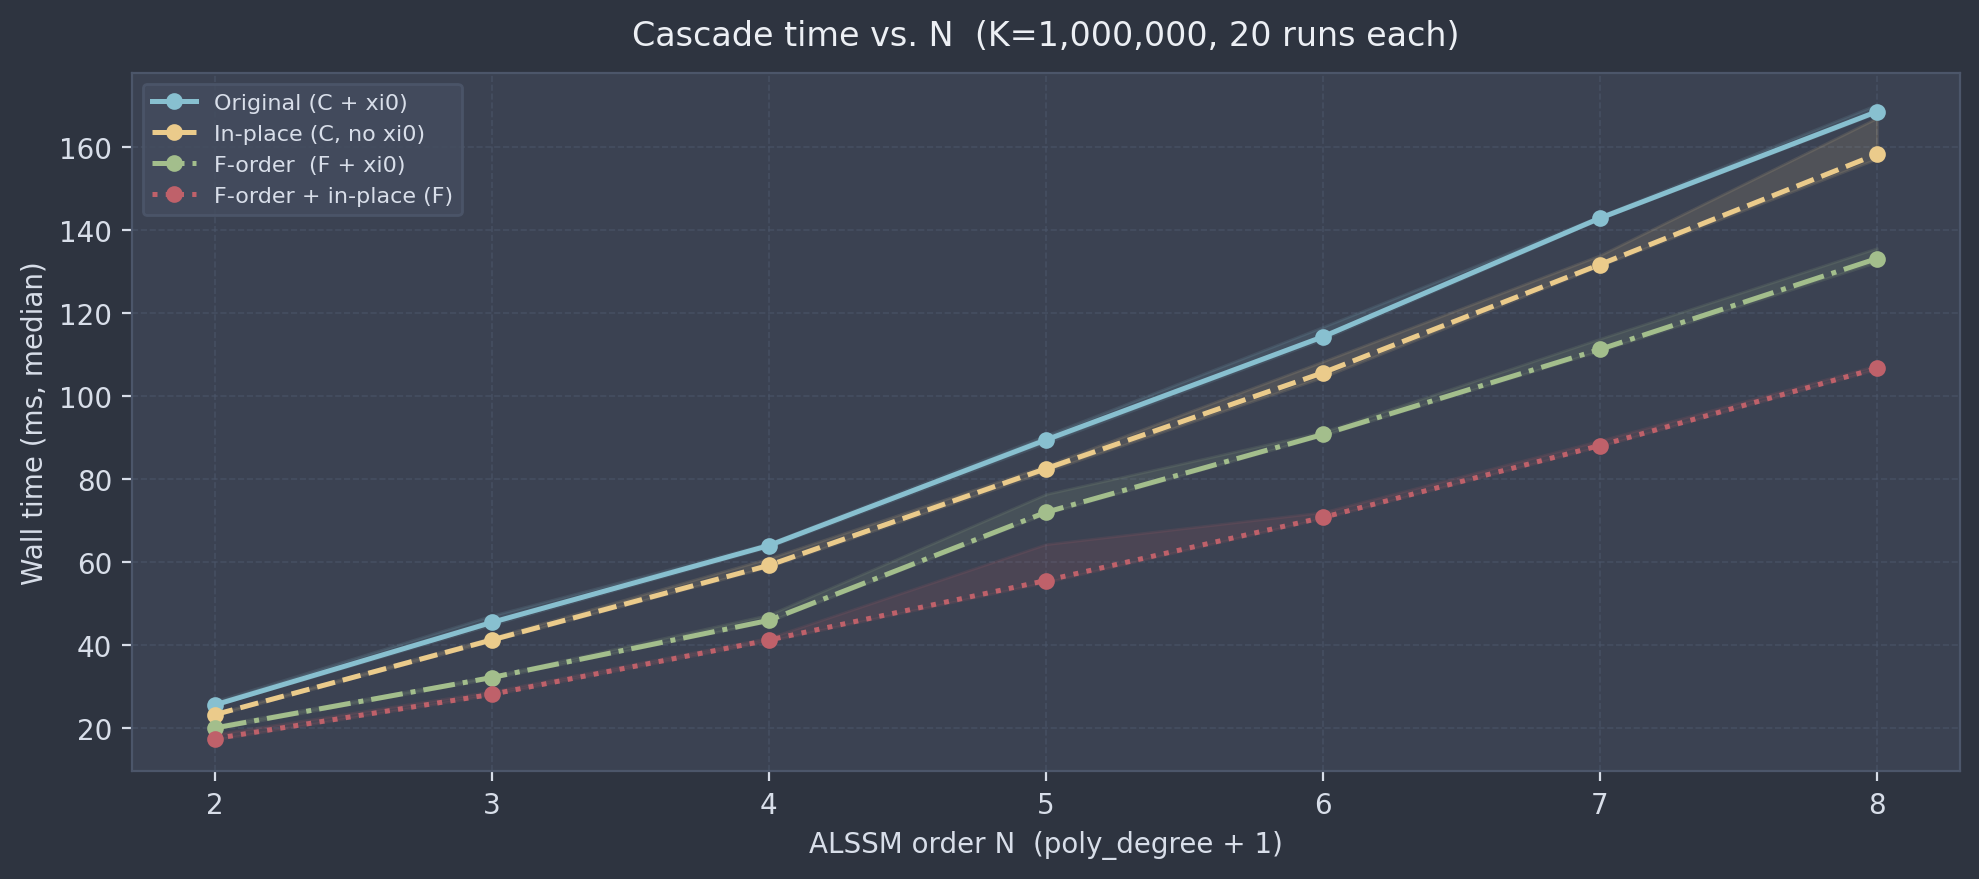

In [ ]:
Ns = N_orders

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])
ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

ls = ['-', '--', '-.', ':']
for vi, (vlab, vcol, vls) in enumerate(zip(var_labels, bar_cols, ls)):
    t_med = [np.median(time_results[N][vi]) for N in Ns]
    t_min = [time_results[N][vi].min()      for N in Ns]
    t_max = [time_results[N][vi].max()      for N in Ns]
    ax.plot(Ns, t_med, color=vcol, marker='o', linewidth=1.8, markersize=5,
            linestyle=vls, label=vlab)
    ax.fill_between(Ns, t_min, t_max, color=vcol, alpha=0.12)

ax.set_xlabel('ALSSM order N  (poly_degree + 1)', color=lm.NORD['fg'])
ax.set_ylabel('Wall time (ms, median)', color=lm.NORD['fg'])
ax.set_title(f'Cascade time vs. N  (K={K:,}, {N_time} runs each)',
             color=lm.NORD['white'], pad=10)
ax.set_xticks(Ns)
ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()

## Total memory sweep

`tracemalloc` measures the **peak simultaneously-live** heap during a single cascade call.
Here `xi` is allocated **inside** the traced block so the output buffer is counted too.

| Variant | Simultaneous live allocations | Peak formula |
|---------|------------------------------|:-------------|
| Scratch (C / F) | `xi` (output) + `xi0` (scratch) | 2 · K · N · 8 B |
| In-place (C / F) | `xi` (output) + einsum temp `(K-1,)` | K · N · 8 B + (K-1) · 8 B ≈ K·(N+1)·8 B |

Both now scale with N, but scratch allocates **2×** as much as in-place.

In [ ]:
mem_results = {}

for p in poly_degrees:
    N = p + 1
    ydm, gAinvT, ginv, _ = build_cascade_inputs(p, seg_l, K)
    vfns = make_variants(gAinvT, ginv, N)

    mem_results[N] = []
    for vi, (vfn, order) in enumerate(zip(vfns, _ord)):
        peaks = []
        for _ in range(N_mem):
            yd = ydm.copy()
            tracemalloc.start()
            xi = np.zeros((K, N), order=order)  # allocate xi inside traced region
            vfn(yd, xi)
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            del xi
            peaks.append(peak / 1024**2)
        mem_results[N].append(np.array(peaks))

    meds = [np.median(mem_results[N][vi]) for vi in range(4)]
    print(f"N={N}:  " + "  ".join(f"{var_labels[vi][:12]}={meds[vi]:.1f}MB" for vi in range(4)))

print("\nMemory sweep done.")

N=2:  Original (C =38.2MB  In-place (C,=22.9MB  F-order  (F =38.2MB  F-order + in=22.9MB
N=3:  Original (C =53.4MB  In-place (C,=30.5MB  F-order  (F =53.4MB  F-order + in=30.5MB
N=4:  Original (C =68.7MB  In-place (C,=38.2MB  F-order  (F =68.7MB  F-order + in=38.2MB
N=5:  Original (C =83.9MB  In-place (C,=45.8MB  F-order  (F =83.9MB  F-order + in=45.8MB
N=6:  Original (C =99.2MB  In-place (C,=53.4MB  F-order  (F =99.2MB  F-order + in=53.4MB
N=7:  Original (C =114.4MB  In-place (C,=61.0MB  F-order  (F =114.4MB  F-order + in=61.0MB
N=8:  Original (C =129.7MB  In-place (C,=68.7MB  F-order  (F =129.7MB  F-order + in=68.7MB

Memory sweep done.


### Peak memory vs N

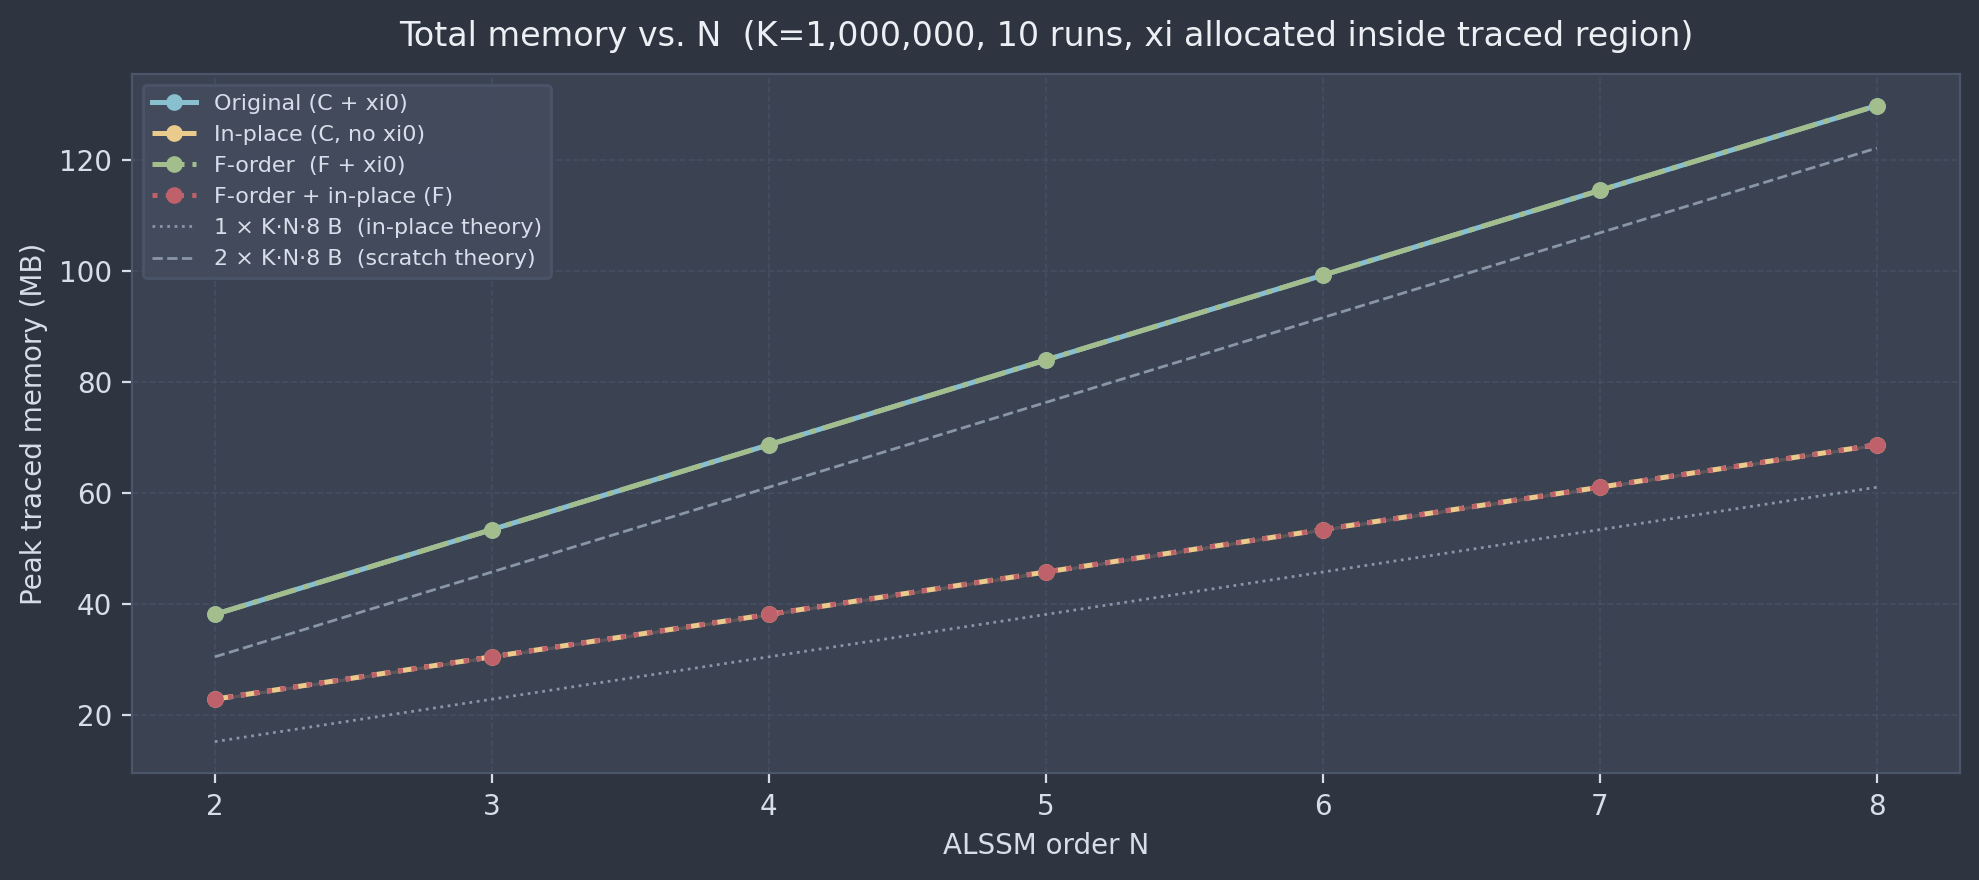

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])
ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

for vi, (vlab, vcol, vls) in enumerate(zip(var_labels, bar_cols, ls)):
    m_med = [np.median(mem_results[N][vi]) for N in Ns]
    m_min = [mem_results[N][vi].min()      for N in Ns]
    m_max = [mem_results[N][vi].max()      for N in Ns]
    ax.plot(Ns, m_med, color=vcol, marker='o', linewidth=1.8, markersize=5,
            linestyle=vls, label=vlab)
    ax.fill_between(Ns, m_min, m_max, color=vcol, alpha=0.12)

# Theoretical reference lines
_grey = '#8896a8'
xi_1x = [K * N * 8 / 1024**2 for N in Ns]
xi_2x = [2 * K * N * 8 / 1024**2 for N in Ns]
ax.plot(Ns, xi_1x, color=_grey, linewidth=1.0, linestyle=':', label='1 × K·N·8 B  (in-place theory)')
ax.plot(Ns, xi_2x, color=_grey, linewidth=1.0, linestyle='--', label='2 × K·N·8 B  (scratch theory)')

ax.set_xlabel('ALSSM order N', color=lm.NORD['fg'])
ax.set_ylabel('Peak traced memory (MB)', color=lm.NORD['fg'])
ax.set_title(f'Total memory vs. N  (K={K:,}, {N_mem} runs, xi allocated inside traced region)',
             color=lm.NORD['white'], pad=10)
ax.set_xticks(Ns)
ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()

## Operation counts vs N

Analytical counts — no profiling overhead.

| Quantity | Formula | Notes |
|----------|---------|-------|
| `lfilter` calls | N | one per cascade dimension |
| `einsum` calls | N − 1 | coupling term, runs from n_=1 |
| `np.zeros` allocs | 0 or 1 | only scratch-buffer variants |
| array `+=` | 0 or 1 | only scratch-buffer variants |
| col write MB | K·N·8 / 2²⁰ | all variants |
| xi0 fill MB | K·N·8 / 2²⁰ | scratch-buffer variants only |
| `+=` dest MB | K·N·8 / 2²⁰ | scratch-buffer variants only |
| **total write MB** | K·N·8·(1 or 3) / 2²⁰ | 3× for scratch, 1× for in-place |


N=2:
  Variant                                  zeros   lfilter   einsum    add    write MB
  ──────────────────────────────────────────────────────────────────────────────
  Original (C + xi0)                           1         2        1      1        45.8
  In-place (C, no xi0)                         0         2        1      0        15.3
  F-order  (F + xi0)                           1         2        1      1        45.8
  F-order + in-place (F)                       0         2        1      0        15.3

N=8:
  Variant                                  zeros   lfilter   einsum    add    write MB
  ──────────────────────────────────────────────────────────────────────────────
  Original (C + xi0)                           1         8        7      1       183.1
  In-place (C, no xi0)                         0         8        7      0        61.0
  F-order  (F + xi0)                           1         8        7      1       183.1
  F-order + in-place (F)                   

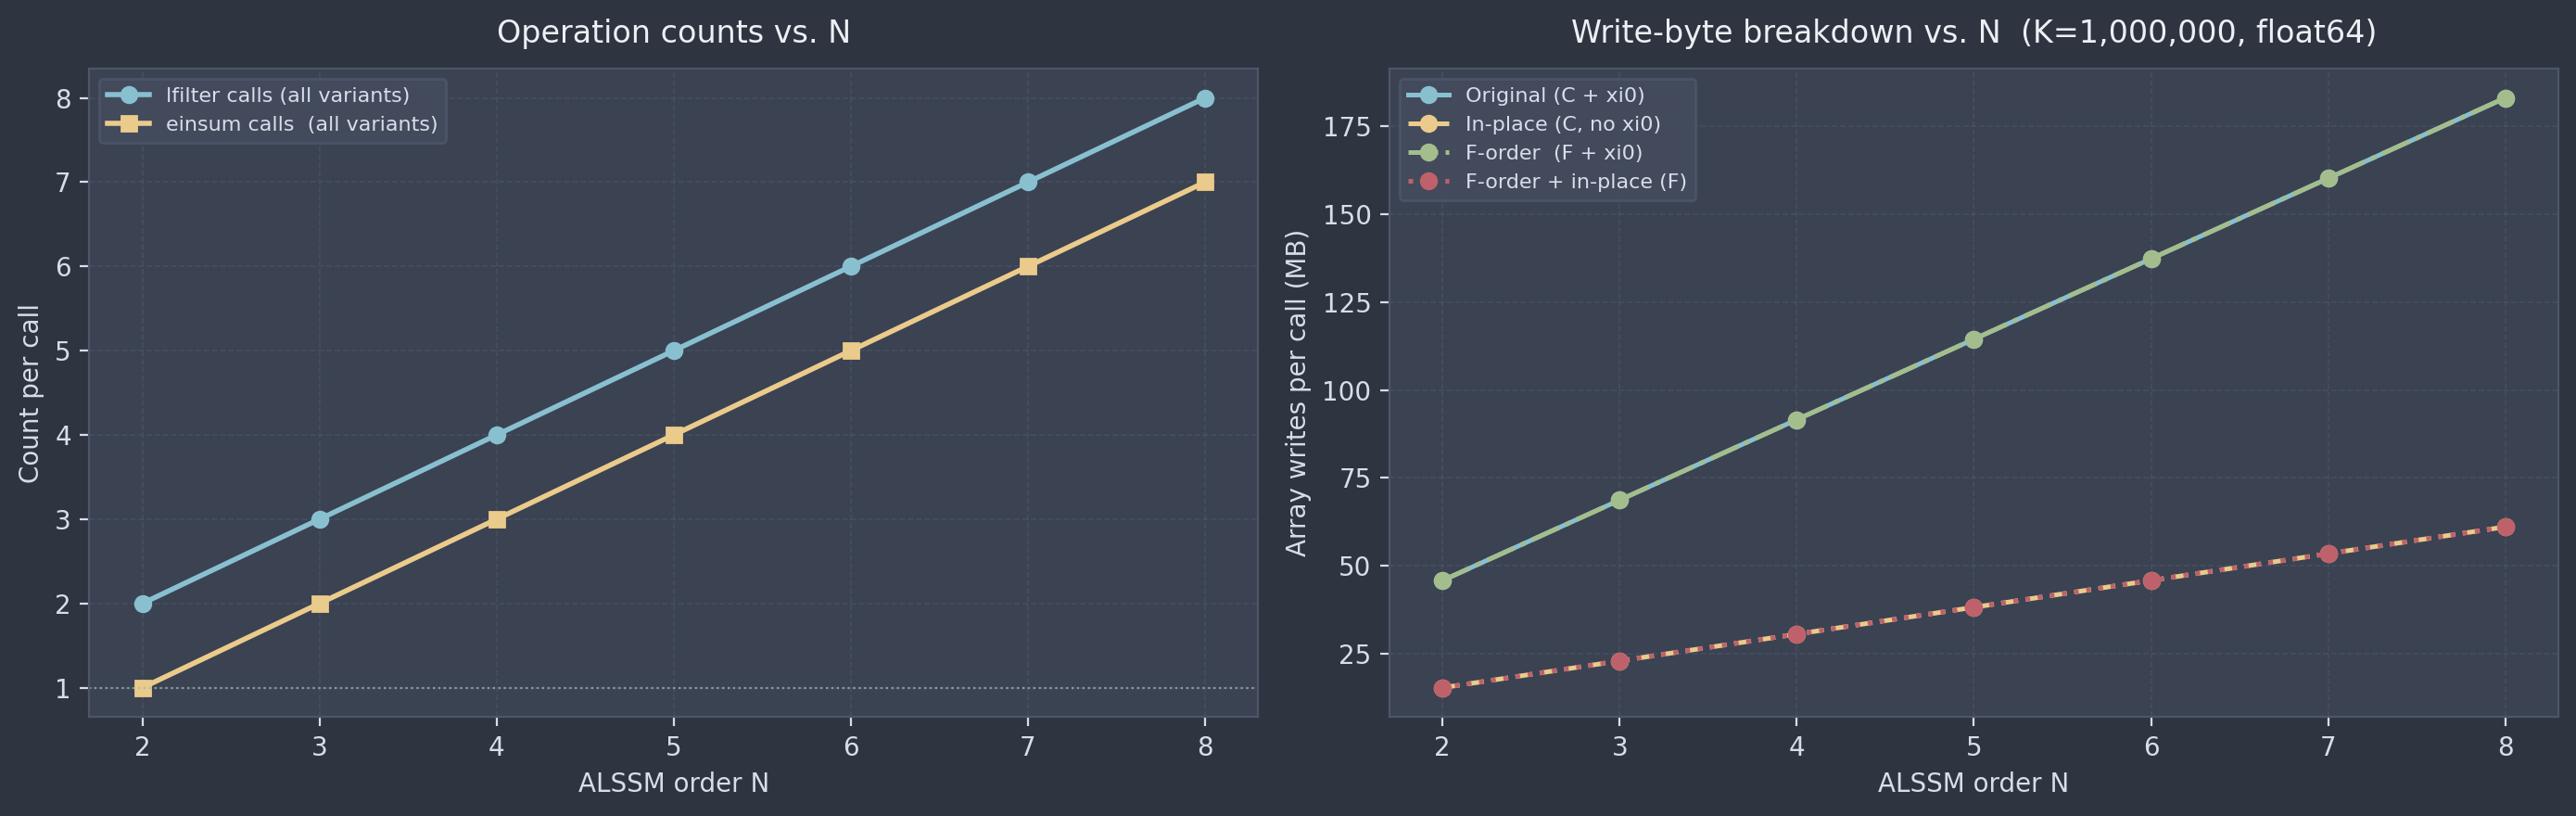

In [ ]:
# ── Analytical operation counts ───────────────────────────────────────────────
ops_N = {}
writes_N = {}
for N in Ns:
    col_mb = K * N * 8 / 1024**2
    ops_N[N] = {
        vlab: {
            'zeros_allocs':  1 if hxi0 else 0,
            'lfilter_calls': N,
            'einsum_calls':  N - 1,
            'array_add':     1 if hxi0 else 0,
        }
        for vlab, hxi0 in zip(var_labels, _has_xi0)
    }
    writes_N[N] = {
        vlab: col_mb * (3 if hxi0 else 1)
        for vlab, hxi0 in zip(var_labels, _has_xi0)
    }

# ── Print summary for two representative Ns ───────────────────────────────────
for N in [2, 8]:
    print(f"\nN={N}:")
    print(f"  {'Variant':<38}  {'zeros':>6}  {'lfilter':>8}  {'einsum':>7}  {'add':>5}  {'write MB':>10}")
    print("  " + "─" * 78)
    for vlab in var_labels:
        o = ops_N[N][vlab]
        print(f"  {vlab:<38}  {o['zeros_allocs']:>6}  {o['lfilter_calls']:>8}  "
              f"{o['einsum_calls']:>7}  {o['array_add']:>5}  {writes_N[N][vlab]:>10.1f}")

# ── Figure: 2 panels — op counts vs N, write MB vs N ─────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in (ax_l, ax_r):
    ax.set_facecolor(lm.NORD['bg2'])
    for sp in ax.spines.values():
        sp.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks(Ns)
    ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
    ax.set_xlabel('ALSSM order N', color=lm.NORD['fg'])

# Left: lfilter and einsum counts (same for all variants — show once)
lf_counts  = [ops_N[N][var_labels[0]]['lfilter_calls'] for N in Ns]  # = N
es_counts  = [ops_N[N][var_labels[0]]['einsum_calls']  for N in Ns]  # = N-1
ax_l.plot(Ns, lf_counts, color=lm.NORD['blue'],   marker='o', linewidth=2, label='lfilter calls (all variants)')
ax_l.plot(Ns, es_counts, color=lm.NORD['yellow'],  marker='s', linewidth=2, label='einsum calls  (all variants)')
# zeros / array+= per variant (0 or 1, constant in N)
for vi, (vlab, vcol) in enumerate(zip(var_labels, bar_cols)):
    if _has_xi0[vi]:
        ax_l.axhline(1, color=vcol, linewidth=0.8, linestyle=':', alpha=0.5)

ax_l.set_ylabel('Count per call', color=lm.NORD['fg'])
ax_l.set_title('Operation counts vs. N', color=lm.NORD['white'], pad=10)
ax_l.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

# Right: write MB per variant
for vi, (vlab, vcol, vls) in enumerate(zip(var_labels, bar_cols, ls)):
    wMB = [writes_N[N][vlab] for N in Ns]
    ax_r.plot(Ns, wMB, color=vcol, marker='o', linewidth=1.8, linestyle=vls, label=vlab)

ax_r.set_ylabel('Array writes per call (MB)', color=lm.NORD['fg'])
ax_r.set_title(f'Write-byte breakdown vs. N  (K={K:,}, float64)', color=lm.NORD['white'], pad=10)
ax_r.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()

## Summary

| Observation | Explanation |
|-------------|-------------|
| Wall time grows super-linearly with N | The coupling einsum dominates at large N: O(K·N²) total vs O(K·N) for lfilter |
| F-order advantage shrinks at large N | At large N the einsum (order-independent) dominates over column-write cost |
| In-place memory saving is constant × N | xi0 is always K×N×8 B → saving scales linearly with N |
| Scratch vs no-scratch write-byte ratio is always 3× | 3·K·N·8 vs 1·K·N·8, independent of N |

**Implication for the production optimization ([ex133.3](example-ex133.3-applied.ipynb))**:
The production model uses `poly_degree=1` (N=2) — the point of **maximum relative F-order benefit**.
At higher N the einsum coupling dominates and the memory-order advantage diminishes, but the
in-place memory saving grows proportionally with N (larger absolute saving at higher orders).
